<a href="https://colab.research.google.com/github/Tienndat2306/TH_DeepLearning_Tuan3/blob/main/ANN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

Tải dữ liệu

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

Trực quan dữ liệu

In [ ]:

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Xử lý dữ liệu

In [ ]:

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape :", y_test_cat.shape)

Xây dựng mô hình

In [ ]:
model = Sequential()

# Chuyển ảnh 28x28 thành vector 784
model.add(Flatten(input_shape=(28, 28)))

# Hidden layer 1
model.add(Dense(units=256, activation="relu"))

model.add(Dropout(0.2))

# Hidden layer 2
model.add(Dense(units=128, activation="relu"))

# Output layer: 10 chữ số
model.add(Dense(units=10, activation="softmax"))


model.compile(
    optimizer='adam',
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Huẩn luyện mô hình

In [ ]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    verbose=1
)

test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

print("\n========== Evaluation Result ==========")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

Biểu đồ đánh giá

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Dự đoán trên bộ dữ liệu

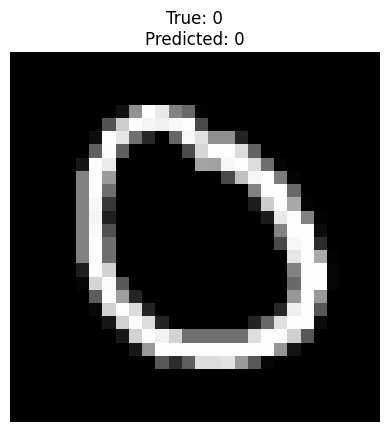


========== Prediction ==========
Real label: 0
Prdicted result: 0
Prediction Probability: 100.0 %


In [6]:
index = np.random.randint(0, len(X_test))

image = X_test[index]
true_label = y_test[index]

prediction = model.predict(image.reshape(1, 28, 28), verbose=0)
predicted_label = np.argmax(prediction)

plt.imshow(image, cmap="gray")
plt.title(
    f"True: {true_label}\n"
    f"Predicted: {predicted_label}"
)
plt.axis("off")
plt.show()

print("\n========== Prediction ==========")
print("Real label:", true_label)
print("Prdicted result:", predicted_label)
print("Prediction Probability:", np.max(prediction) * 100, "%")

Dự đoán bằng hình ảnh được tải lên

Vui lòng chọn một ảnh để tải lên:


Saving 9.png to 9.png
Đường dẫn ảnh đã chọn: 9.png


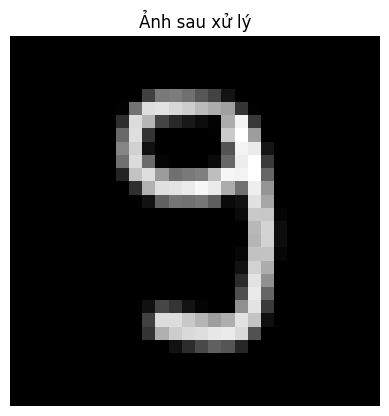

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

========== KẾT QUẢ DỰ ĐOÁN ==========
Number: 9
Reliability: 68.81%


In [11]:
from google.colab import files
from PIL import Image
import io

print("Vui lòng chọn một ảnh để tải lên:")
uploaded = files.upload()

file_path = list(uploaded.keys())[0]

print("Đường dẫn ảnh đã chọn:", file_path)

# Use io.BytesIO to open the uploaded file content
img = Image.open(io.BytesIO(uploaded[file_path]))

# Chuyển grayscale
img = img.convert("L")

# Resize về 28x28
img = img.resize((28, 28))

# Chuyển sang numpy array
img_array = np.array(img)

# =====================================================
# ĐẢO MÀU
# =====================================================

# MNIST:
# nền đen - chữ trắng
# nên cần đảo màu nếu ảnh upload là nền trắng

img_array = 255 - img_array


img_array = img_array.astype("float32") / 255.0


plt.imshow(img_array, cmap="gray")

plt.title("Ảnh sau xử lý")

plt.axis("off")

plt.show()


img_input = img_array.reshape(1, 28, 28)


prediction = model.predict(img_input)

predicted_label = np.argmax(prediction)

confidence = np.max(prediction) * 100


print("\n========== KẾT QUẢ DỰ ĐOÁN ==========")

print("Number:", predicted_label)

print(f"Reliability: {confidence:.2f}%")